# multi linear model

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('2_oil_cost_analysis_dataset.csv')
df.head()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52


In [8]:
df2=df.duplicated()
df2.value_counts()

False    5000
Name: count, dtype: int64

In [9]:
df.isnull().sum()

FlowRate_LPM    0
Pressure_Bar    0
TankLevel_L     0
OilCost_$       0
dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df.corr()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
FlowRate_LPM,1.000000,-0.007015,-0.009517,0.824780
Pressure_Bar,-0.007015,1.000000,-0.022837,0.212833
TankLevel_L,-0.009517,-0.022837,1.000000,0.508463
OilCost_$,0.824780,0.212833,0.508463,1.000000


<Axes: >

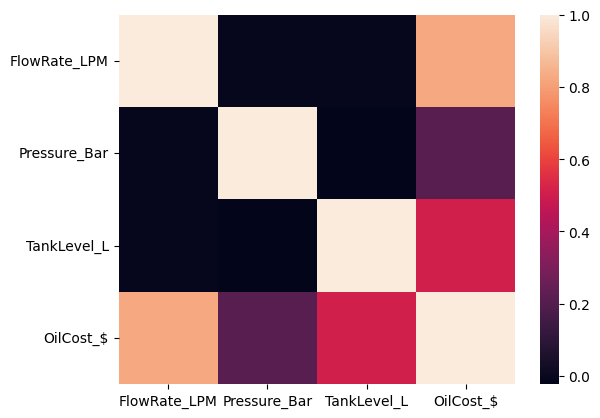

In [12]:
sns.heatmap(df.corr())

In [13]:
df

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52
...,...,...,...,...
4995,458.96,71.46,3603.53,654.53
4996,147.75,73.85,1711.19,314.54
4997,231.14,76.80,1204.96,360.36
4998,426.30,43.85,3731.85,593.40


In [14]:
df.describe()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,298.732838,49.489212,3005.500244,463.495078
std,115.853453,17.137032,1163.079301,111.483085
min,100.000000,20.000000,1000.630000,176.560000
25%,197.547500,34.827500,1988.670000,380.497500
50%,300.000000,49.155000,2984.790000,464.480000
75%,399.240000,64.000000,4042.475000,544.907500
max,499.890000,79.970000,4999.220000,753.320000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FlowRate_LPM  5000 non-null   float64
 1   Pressure_Bar  5000 non-null   float64
 2   TankLevel_L   5000 non-null   float64
 3   OilCost_$     5000 non-null   float64
dtypes: float64(4)
memory usage: 156.4 KB


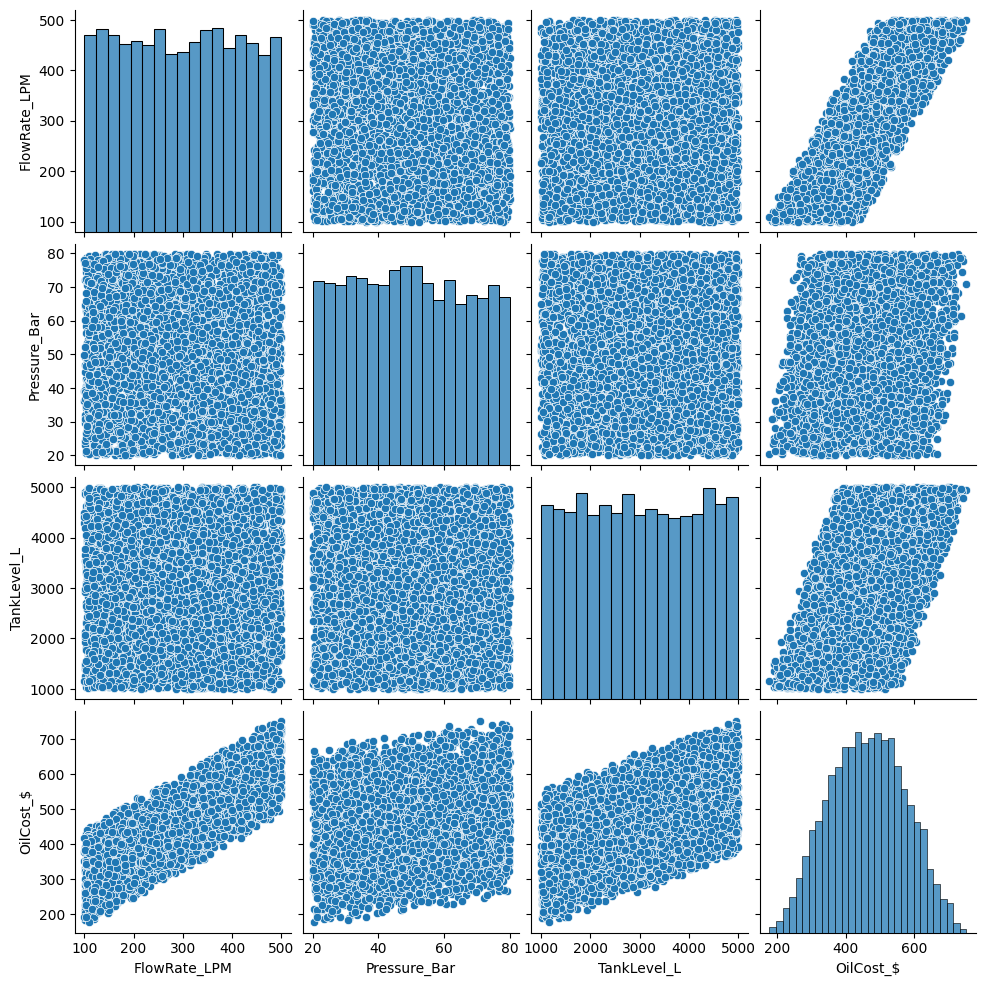

In [16]:
sns.pairplot(df)

In [17]:
df.corr(method='pearson')

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
FlowRate_LPM,1.000000,-0.007015,-0.009517,0.824780
Pressure_Bar,-0.007015,1.000000,-0.022837,0.212833
TankLevel_L,-0.009517,-0.022837,1.000000,0.508463
OilCost_$,0.824780,0.212833,0.508463,1.000000


Text(0.5, 0, 'FlowRate_LPM')

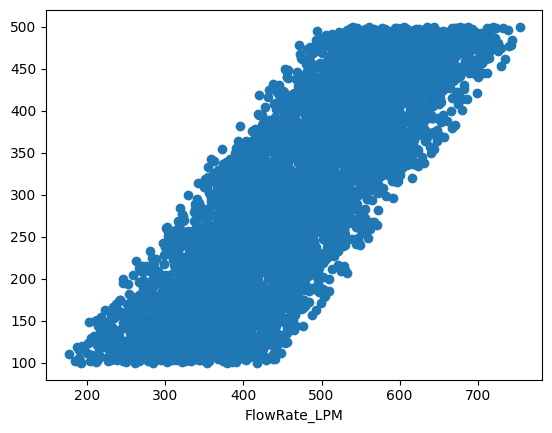

In [18]:
plt .scatter(df['OilCost_$'],df['FlowRate_LPM'])
plt.xlabel('oil cost')
plt.xlabel('FlowRate_LPM')

In [19]:
df.head()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52


In [20]:
#independent and dependent features 

x = df.iloc[:, :3]  # Features: FlowRate_LPM, Pressure_Bar, TankLevel_L
y = df.iloc[:, 3]   # Target: OilCost_$

print("Features:", x.columns.tolist())
print("Target:", y.name)
print("X shape:", x.shape)
print("y shape:", y.shape)

Features: ['FlowRate_LPM', 'Pressure_Bar', 'TankLevel_L']
Target: OilCost_$
X shape: (5000, 3)
y shape: (5000,)


In [21]:
x

,FlowRate_LPM,Pressure_Bar,TankLevel_L
0,249.82,43.62,2494.56
1,480.29,48.41,2331.65
2,392.80,71.27,1704.62
3,339.46,40.40,3429.07
4,162.41,72.18,2906.50
...,...,...,...
4995,458.96,71.46,3603.53
4996,147.75,73.85,1711.19
4997,231.14,76.80,1204.96
4998,426.30,43.85,3731.85


In [22]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [23]:
x_train.iloc[:,0]

4884    143.95
3163    301.05
490     282.26
862     309.76
1740    431.02
         ...  
4426    194.77
466     214.28
3092    259.61
3772    237.58
860     410.21
Name: FlowRate_LPM, Length: 3750, dtype: float64

In [24]:
y_train.shape

(3750,)

In [25]:
from sklearn.preprocessing import StandardScaler

scalar=StandardScaler()


In [26]:
# Fix: Properly apply scaling and save the transformed data
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

print("Scaling applied successfully")
print("x_train_scaled shape:", x_train_scaled.shape)
print("x_test_scaled shape:", x_test_scaled.shape)

Scaling applied successfully
x_train_scaled shape: (3750, 3)
x_test_scaled shape: (1250, 3)


In [27]:
from sklearn.linear_model import LinearRegression

regress=LinearRegression()

In [28]:
# Train the model with scaled data
regress.fit(x_train_scaled, y_train)

LinearRegression()

In [29]:
from sklearn.model_selection import cross_val_score

val_scor=cross_val_score(regress,x_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [30]:
val_scor

array([-3.18859687e-05, -3.00014155e-05, -3.23149877e-05])

In [31]:
np.mean(val_scor)

np.float64(-3.140079063288327e-05)

In [32]:
x_train,x_test

(      FlowRate_LPM  Pressure_Bar  TankLevel_L
 4884        143.95         23.29      2679.36
 3163        301.05         48.86      1396.23
 490         282.26         29.38      1985.91
 862         309.76         20.45      1432.58
 1740        431.02         30.27      2289.33
 ...            ...           ...          ...
 4426        194.77         37.12      3827.64
 466         214.28         66.66      2695.82
 3092        259.61         55.15      1679.36
 3772        237.58         53.37      4072.99
 860         410.21         47.32      4798.15
 
 [3750 rows x 3 columns],
       FlowRate_LPM  Pressure_Bar  TankLevel_L
 1501        291.67         24.80      4537.99
 2586        128.71         45.05      1834.11
 2653        120.94         68.74      2820.21
 1055        240.28         49.58      2385.45
 705         495.98         35.94      3356.85
 ...            ...           ...          ...
 4141        153.83         31.90      3820.76
 3168        405.78         46.1

In [33]:
y_train,y_test

(4884    284.07
 3163    383.94
 490     369.18
 862     350.11
 1740    504.68
          ...  
 4426    402.88
 466     406.21
 3092    374.39
 3772    473.78
 860     639.06
 Name: OilCost_$, Length: 3750, dtype: float64,
 1501    497.44
 2586    262.24
 2653    340.87
 1055    385.87
 705     618.54
          ...  
 4141    361.96
 3168    556.21
 2478    332.80
 4214    443.96
 4180    346.35
 Name: OilCost_$, Length: 1250, dtype: float64)

In [34]:
# Make predictions using scaled test data
y_pred = regress.predict(x_test_scaled)

In [35]:
y_pred

array([497.43574446, 262.24826926, 340.87225433, ..., 332.79565795,
       443.96204927, 346.34825129], shape=(1250,))

In [36]:
from sklearn.metrics import r2_score

score=r2_score(y_test,y_pred)
perc=(score*100)
perc

99.99999975568845

In [37]:
from sklearn.metrics import r2_score

# Calculate R-squared
score = r2_score(y_test, y_pred)
print("r2->",score)

# Display Adjusted R-squared
print(1 - (1 - score) * ((len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)))

r2-> 0.9999999975568845
0.9999999975510022


In [38]:
y_test

1501    497.44
2586    262.24
2653    340.87
1055    385.87
705     618.54
         ...  
4141    361.96
3168    556.21
2478    332.80
4214    443.96
4180    346.35
Name: OilCost_$, Length: 1250, dtype: float64

In [39]:
y_pred

array([497.43574446, 262.24826926, 340.87225433, ..., 332.79565795,
       443.96204927, 346.34825129], shape=(1250,))

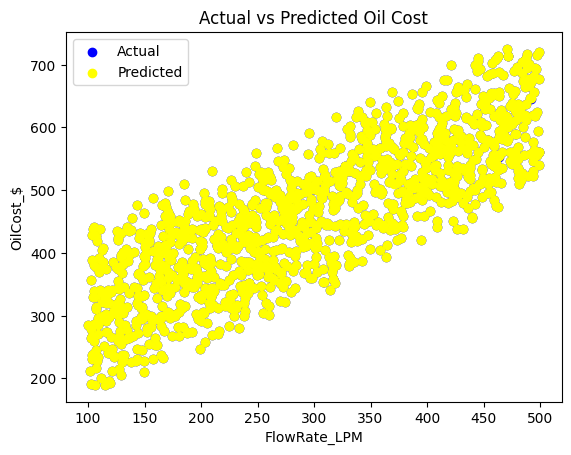

In [40]:
plt.scatter(x_test.iloc[:,0], y_test, color='blue', label='Actual')
plt.scatter(x_test.iloc[:,0], y_pred, color='yellow', label='Predicted')
plt.xlabel('FlowRate_LPM')
plt.ylabel('OilCost_$')
plt.title('Actual vs Predicted Oil Cost')
plt.legend()
plt.show()

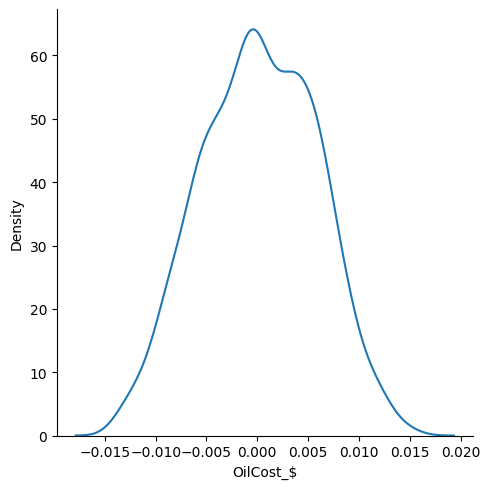

In [41]:
# assumptions
residuals=y_test-y_pred
# residuals.head(10)
sns.displot(residuals,kind='kde')

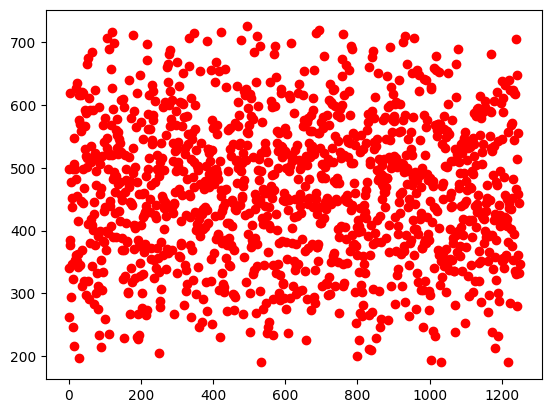

In [42]:
x=range(len(y_test))

plt.scatter(x,y_test,color='red')


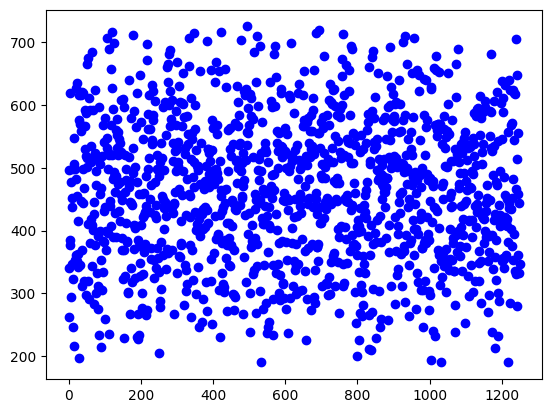

In [43]:
plt.scatter(x,y_pred,color='blue')

In [44]:
df.head()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52


In [45]:
# Predicting with proper scaling
# Input: [FlowRate_LPM, Pressure_Bar, TankLevel_L]
new_data = [[676.82, 23.41, 1111]]
new_data_scaled = scalar.transform(new_data)
predicted_cost = regress.predict(new_data_scaled)[0]

print(f"The cost of oil will be ${predicted_cost:.2f}")

The cost of oil will be $632.12


In [46]:
import pickle

In [57]:
# Save both the model and the fitted scaler
with open('oil_cost_predict_model.pkl','wb') as file:
    pickle.dump(regress,file)

# Save the fitted scaler separately
with open('oil_cost_scaler.pkl','wb') as file:
    pickle.dump(scalar,file)

print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!


In [48]:
with open('oil_cost_predict_model.pkl','rb') as file:
    model=pickle.load(file)

    

In [49]:
import warnings

warnings.filterwarnings('ignore')

In [50]:
# ❌ DANGEROUS PREDICTION (Using raw data with scaled model)
print("DANGEROUS PREDICTION (raw data):", (model.predict([[456.82,44.41,2211]])[0]).round(2), "$")

# ✅ CORRECT PREDICTION (Using scaled data)
input_data = [[456.82, 44.41, 2211]]  # [FlowRate_LPM, Pressure_Bar, TankLevel_L]
input_scaled = scalar.transform(input_data)  # Apply the same scaling used during training
correct_prediction = model.predict(input_scaled)[0]

print("CORRECT PREDICTION (scaled data):", correct_prediction.round(2), "$")

# Show the difference
difference = abs(model.predict([[456.82,44.41,2211]])[0] - correct_prediction)
print(f"Difference: ${difference:.2f} - This is why scaling is crucial!")

DANGEROUS PREDICTION (raw data): 171985.64 $
CORRECT PREDICTION (scaled data): 542.62 $
Difference: $171443.02 - This is why scaling is crucial!


In [51]:
# 🔍 PREDICTION VALIDATION - Check if predictions are reasonable
print("=== PREDICTION VALIDATION ===")
print(f"Training data oil cost range: ${df['OilCost_$'].min():.2f} - ${df['OilCost_$'].max():.2f}")
print(f"Average oil cost: ${df['OilCost_$'].mean():.2f}")
print(f"Standard deviation: ${df['OilCost_$'].std():.2f}")

# Input parameters
flow_rate = 456.82
pressure = 44.41
tank_level = 2211

print(f"\nInput Parameters:")
print(f"FlowRate: {flow_rate} LPM")
print(f"Pressure: {pressure} Bar") 
print(f"TankLevel: {tank_level} L")

# Check if input is within training data range
print(f"\nInput Range Check:")
print(f"FlowRate range in training: {df['FlowRate_LPM'].min():.2f} - {df['FlowRate_LPM'].max():.2f}")
print(f"Pressure range in training: {df['Pressure_Bar'].min():.2f} - {df['Pressure_Bar'].max():.2f}")
print(f"TankLevel range in training: {df['TankLevel_L'].min():.2f} - {df['TankLevel_L'].max():.2f}")

# Final prediction with confidence
input_data = [[flow_rate, pressure, tank_level]]
input_scaled = scalar.transform(input_data)
final_prediction = model.predict(input_scaled)[0]

print(f"\n✅ FINAL SAFE PREDICTION: ${final_prediction:.2f}")

# Sanity check
if final_prediction < df['OilCost_$'].min() or final_prediction > df['OilCost_$'].max():
    print("⚠️  WARNING: Prediction is outside training data range!")
else:
    print("✅ Prediction is within reasonable range")

=== PREDICTION VALIDATION ===
Training data oil cost range: $176.56 - $753.32
Average oil cost: $463.50
Standard deviation: $111.48

Input Parameters:
FlowRate: 456.82 LPM
Pressure: 44.41 Bar
TankLevel: 2211 L

Input Range Check:
FlowRate range in training: 100.00 - 499.89
Pressure range in training: 20.00 - 79.97
TankLevel range in training: 1000.63 - 4999.22

✅ FINAL SAFE PREDICTION: $542.62
✅ Prediction is within reasonable range


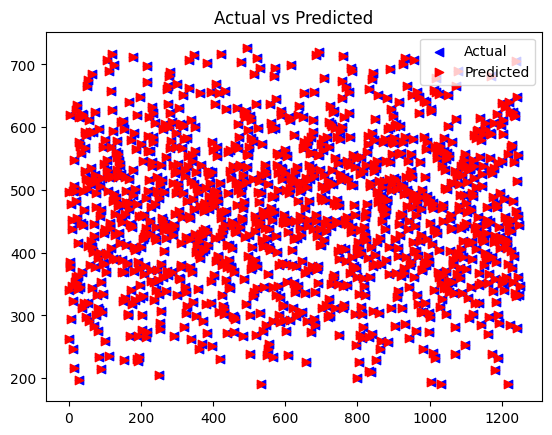

In [52]:
plt.scatter(range(len(y_test)), y_test, label='Actual', color='blue',marker='<')
plt.scatter(range(len(y_pred)), y_pred, label='Predicted', color='red', marker='>')


plt.title('Actual vs Predicted')
plt.legend()
plt.show()

Text(0.5, 1.0, ' Actual vs Predicted')

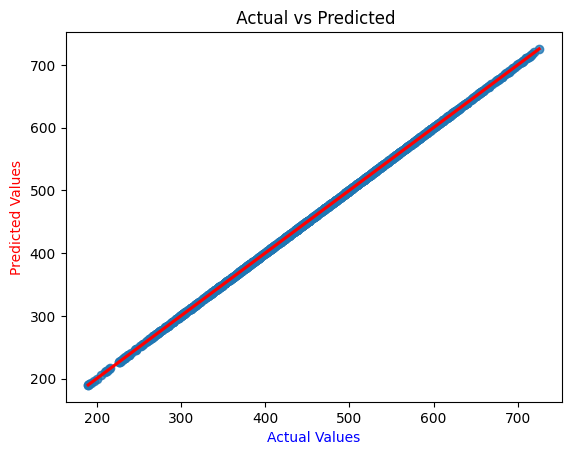

In [53]:
sns.regplot(x=y_test, y=y_pred, label=['Actual','predicted'], line_kws={"color":"red"})
plt.xlabel('Actual Values',color='blue')
plt.ylabel('Predicted Values',color='red')
plt.title(' Actual vs Predicted')

In [54]:
# Comprehensive Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== MODEL EVALUATION METRICS ===")
print(f"R² Score: {r2:.6f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Oil Cost in Test Set: ${y_test.mean():.2f}")
print(f"RMSE as % of Mean: {(rmse/y_test.mean())*100:.4f}%")

# Check if the perfect score is suspicious
if r2 > 0.999:
    print("\n⚠️  WARNING: R² score > 99.9% is suspiciously high!")
    print("This might indicate:")
    print("1. Data leakage")
    print("2. Synthetic/artificial dataset")
    print("3. Perfect linear relationship")
    
# Check residuals distribution
residuals = y_test - y_pred
print(f"\nResiduals Stats:")
print(f"Mean residual: {residuals.mean():.6f}")
print(f"Std residual: {residuals.std():.6f}")
print(f"Max absolute residual: ${abs(residuals).max():.6f}")

=== MODEL EVALUATION METRICS ===
R² Score: 1.000000
Mean Absolute Error (MAE): $0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): $0.01
Mean Oil Cost in Test Set: $462.27
RMSE as % of Mean: 0.0012%

⚠️  WARNING: R² score > 99.9% is suspiciously high!
This might indicate:
1. Data leakage
2. Synthetic/artificial dataset
3. Perfect linear relationship

Residuals Stats:
Mean residual: 0.000177
Std residual: 0.005641
Max absolute residual: $0.015270


In [55]:
df.head()

,FlowRate_LPM,Pressure_Bar,TankLevel_L,OilCost_$
0,249.82,43.62,2494.56,390.01
1,480.29,48.41,2331.65,573.42
2,392.80,71.27,1704.62,506.38
3,339.46,40.40,3429.07,503.62
4,162.41,72.18,2906.50,383.52


In [62]:
import warnings
import pickle
warnings.filterwarnings('ignore')

print("Enter oil cost prediction parameters:")
print("Valid ranges:")
print("- FlowRate_LPM: 100.00 - 499.89")
print("- Pressure_Bar: 20.00 - 79.97") 
print("- TankLevel_L: 1000.63 - 4999.22")
print()

def get_pred(arr):
    # Convert string inputs to float
    FlowRate_LPM = float(arr[0])
    Pressure_Bar = float(arr[1])
    TankLevel_L = float(arr[2])
    
    with open('oil_cost_predict_model.pkl','rb') as file:
        model = pickle.load(file)
    
    with open('oil_cost_scaler.pkl','rb') as file:
        fitted_scaler = pickle.load(file)
    
   
    input_data = [[FlowRate_LPM, Pressure_Bar, TankLevel_L]] 
    input_scaled = fitted_scaler.transform(input_data)
    correct_prediction = model.predict(input_scaled)[0]

    return float(correct_prediction)

# Get user inputs
parameters = ["FlowRate_LPM", "Pressure_Bar", "TankLevel_L"]    
input_parameters = []    


for i in range(0, 3):
    value = input(f"Give input for {parameters[i]}: ")
    input_parameters.append(value)

# Make prediction
try:
    prediction = get_pred(input_parameters)
    print(f" Oil cost : ${prediction:.2f}")
except ValueError as e:
    print(f"Input Error: {e}")
    print("Make sure to enter numeric values only!")
except FileNotFoundError as e:
    print(f"File Error: {e}")
    print("Make sure the model and scaler files are saved first!")
except Exception as e:
    print(f"Unexpected Error: {e}")

Enter oil cost prediction parameters:
Valid ranges:
- FlowRate_LPM: 100.00 - 499.89
- Pressure_Bar: 20.00 - 79.97
- TankLevel_L: 1000.63 - 4999.22

 Oil cost : $445.95
 Oil cost : $445.95
